<a href="https://colab.research.google.com/github/wetjie/BTPR3203-Python-for-Data-Science-2026B-Case-Study/blob/main/B240022A_Case%20Study_BTPR3203_2026B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 3.2: DATA PREPARATION AND UNDERSTANDING

[1] Loading datasets...
Water Consumption records: 600
Water Consumption columns: 4
IPI records: 398
IPI columns: 4

[2] Water Consumption Structure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   state   600 non-null    object
 1   sector  600 non-null    object
 2   date    600 non-null    object
 3   value   600 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 18.9+ KB

[3] IPI Structure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   series    398 non-null    object 
 1   date      398 non-null    object 
 2   index     398 non-null    float64
 3   index_sa  398 non-null    float64
dtypes: float64(2), object(2)
memory usage: 12.6+ KB

Water Consumption colum

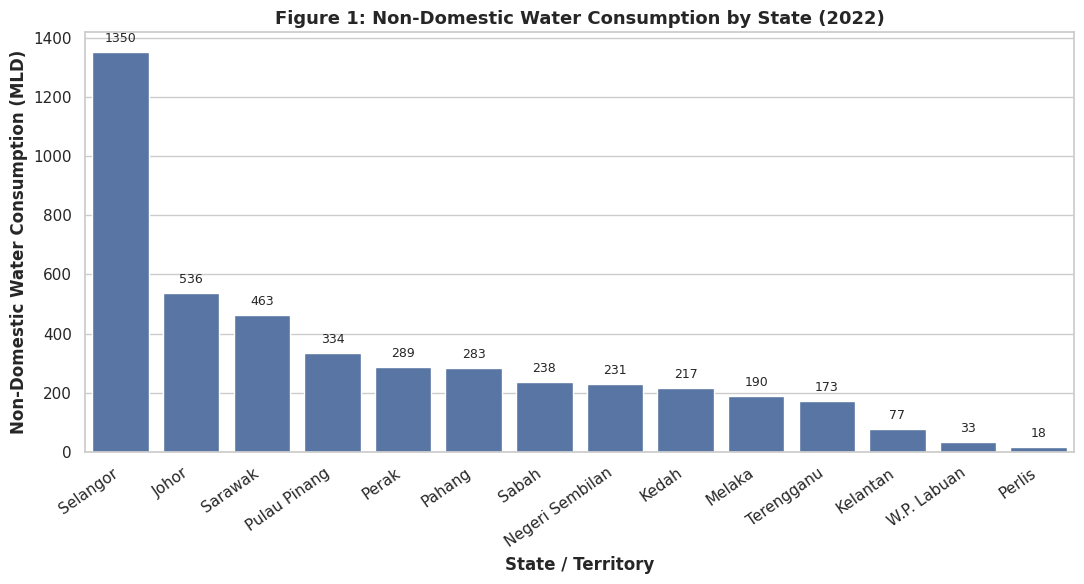


Generating growth-rate visualisation...


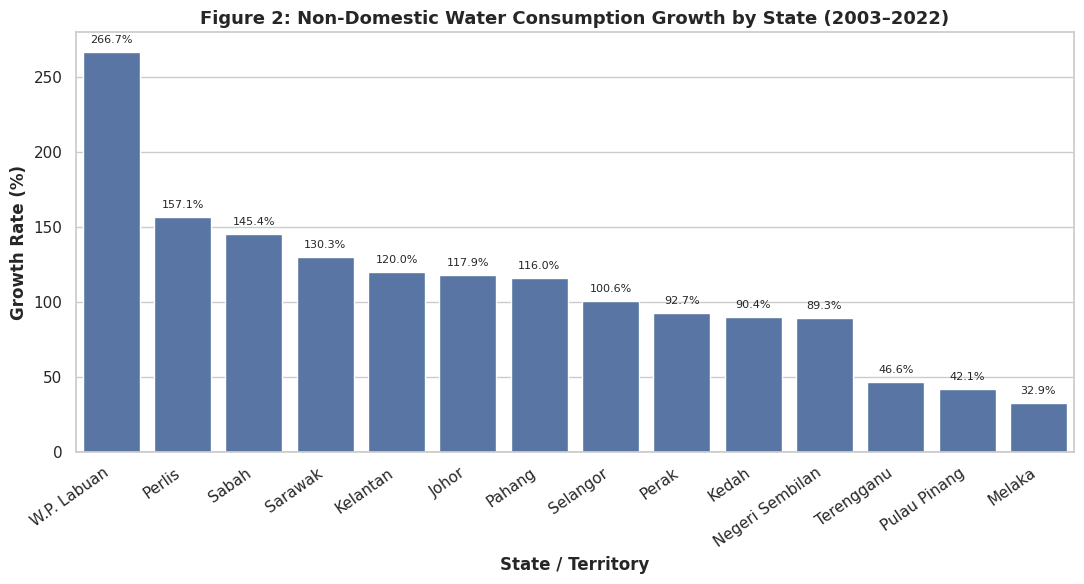

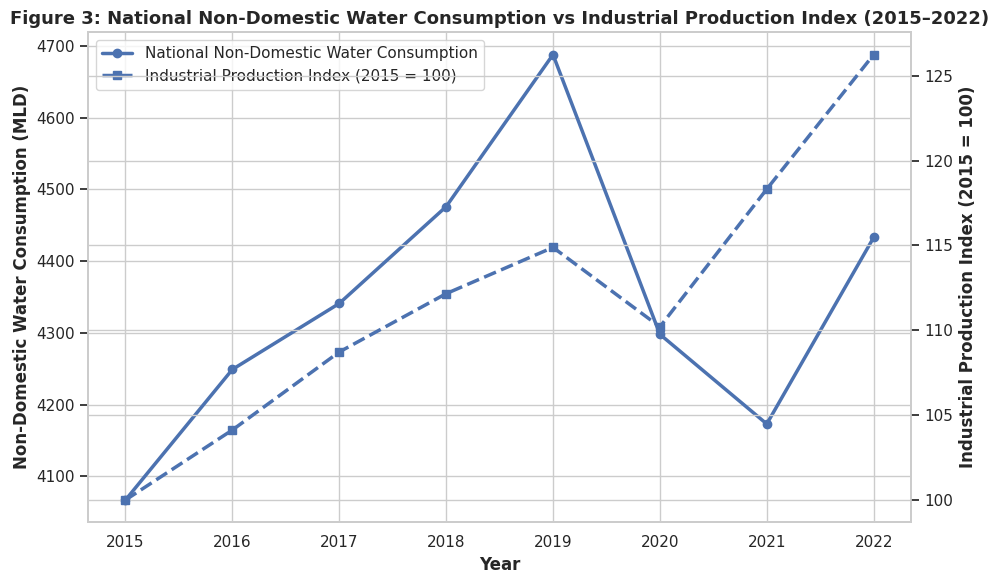


[SUCCESS] Three high-resolution visualisations generated successfully.

Generated files:
1. fig1_nondomestic_water_by_state_2022.png
2. fig2_nondomestic_water_growth_2003_2022.png
3. fig3_national_water_vs_ipi.png

PIPELINE COMPLETED SUCCESSFULLY

Final outputs:
- cleaned_water_consumption_by_state.csv
- cleaned_national_water_vs_ipi.csv
- fig1_nondomestic_water_by_state_2022.png
- fig2_nondomestic_water_growth_2003_2022.png
- fig3_national_water_vs_ipi.png


In [2]:
"""
BTPR3203 Python for Data Science - Case Study
Author: Lim Wet Jie
Institution: Southern University College

Case Study:
Sustainable Industrial Activity in Malaysia:
Water Consumption and Industrial Production

Data Sources:
1. water_consumption.csv
   Source: Department of Statistics Malaysia (DOSM), data.gov.my
   https://data.gov.my/data-catalogue/water_consumption

2. ipi.csv
   Source: Department of Statistics Malaysia (DOSM), data.gov.my
   https://data.gov.my/data-catalogue/ipi
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# STEP 3.2
# DATA PREPARATION AND UNDERSTANDING
# ============================================================

def prepare_data():

    print("=" * 70)
    print("STEP 3.2: DATA PREPARATION AND UNDERSTANDING")
    print("=" * 70)

    # ========================================================
    # RQ1:
    # Prepare and transform the raw datasets into reliable
    # indicators for sustainable industrial analysis.
    # ========================================================

    # --------------------------------------------------------
    # 1. Load datasets
    # --------------------------------------------------------
    print("\n[1] Loading datasets...")

    wc_raw = pd.read_csv("water_consumption.csv")
    ipi_raw = pd.read_csv("ipi.csv")

    print(f"Water Consumption records: {len(wc_raw)}")
    print(f"Water Consumption columns: {len(wc_raw.columns)}")
    print(f"IPI records: {len(ipi_raw)}")
    print(f"IPI columns: {len(ipi_raw.columns)}")

    # --------------------------------------------------------
    # 2. Examine structure and data types
    # --------------------------------------------------------
    print("\n[2] Water Consumption Structure")
    wc_raw.info()

    print("\n[3] IPI Structure")
    ipi_raw.info()

    print("\nWater Consumption columns:")
    print(wc_raw.columns.tolist())

    print("\nIPI columns:")
    print(ipi_raw.columns.tolist())

    print("\nWater Consumption data types:")
    print(wc_raw.dtypes)

    print("\nIPI data types:")
    print(ipi_raw.dtypes)

    # --------------------------------------------------------
    # 3. Descriptive statistics
    # --------------------------------------------------------
    print("\n[4] Water Consumption Descriptive Statistics")
    print(wc_raw.describe(include="all"))

    print("\n[5] IPI Descriptive Statistics")
    print(ipi_raw.describe(include="all"))

    # --------------------------------------------------------
    # 4. Missing-value checking
    # --------------------------------------------------------
    print("\n[6] Missing Value Check - Before Cleaning")

    wc_missing_before = wc_raw.isnull().sum()
    ipi_missing_before = ipi_raw.isnull().sum()

    print("\nWater Consumption missing values:")
    print(wc_missing_before)

    print("\nIPI missing values:")
    print(ipi_missing_before)

    # --------------------------------------------------------
    # 5. Duplicate checking
    # --------------------------------------------------------
    print("\n[7] Duplicate Record Check")

    wc_duplicates = wc_raw.duplicated().sum()
    ipi_duplicates = ipi_raw.duplicated().sum()

    print(f"Water Consumption exact duplicates: {wc_duplicates}")
    print(f"IPI exact duplicates: {ipi_duplicates}")

    # --------------------------------------------------------
    # 6. Data consistency checking
    # --------------------------------------------------------
    print("\n[8] Data Consistency Check")

    print("\nWater Consumption sectors:")
    print(wc_raw["sector"].unique())

    print("\nWater Consumption states:")
    print(wc_raw["state"].unique())

    print("\nIPI series:")
    print(ipi_raw["series"].unique())

    # Expected water consumption sector values
    expected_wc_sectors = {"domestic", "nondomestic"}
    observed_wc_sectors = set(
        wc_raw["sector"].dropna().unique()
    )

    unexpected_wc_sectors = (
        observed_wc_sectors - expected_wc_sectors
    )

    print(
        "\nUnexpected water consumption sector values: "
        f"{unexpected_wc_sectors if unexpected_wc_sectors else 'None'}"
    )

    # Expected IPI series values
    expected_ipi_series = {
        "abs",
        "growth_yoy",
        "growth_mom"
    }

    observed_ipi_series = set(
        ipi_raw["series"].dropna().unique()
    )

    unexpected_ipi_series = (
        observed_ipi_series - expected_ipi_series
    )

    print(
        "Unexpected IPI series values: "
        f"{unexpected_ipi_series if unexpected_ipi_series else 'None'}"
    )

    # Negative water consumption check
    negative_water = (
        wc_raw["value"] < 0
    ).sum()

    # Negative IPI check only for absolute series.
    # Negative growth rates are valid observations and are
    # therefore not treated as invalid absolute IPI values.
    ipi_abs_raw = ipi_raw[
        ipi_raw["series"] == "abs"
    ].copy()

    negative_abs_ipi = (
        ipi_abs_raw["index"] < 0
    ).sum()

    print(
        "\nNegative water consumption values: "
        f"{negative_water}"
    )

    print(
        "Negative IPI index values in abs series: "
        f"{negative_abs_ipi}"
    )

    # --------------------------------------------------------
    # 7. Remove exact duplicate records
    # --------------------------------------------------------
    # Exact duplicate rows are removed because repeated
    # observations would otherwise affect later calculations.
    wc_clean = wc_raw.drop_duplicates().copy()
    ipi_clean = ipi_raw.drop_duplicates().copy()

    print("\nAfter exact duplicate removal:")
    print(f"Water Consumption: {len(wc_clean)} records")
    print(f"IPI: {len(ipi_clean)} records")

    # --------------------------------------------------------
    # 8. Convert date columns
    # --------------------------------------------------------
    # Conversion to datetime is required for reliable yearly
    # extraction and alignment between the two datasets.
    wc_clean["date"] = pd.to_datetime(
        wc_clean["date"],
        errors="coerce"
    )

    ipi_clean["date"] = pd.to_datetime(
        ipi_clean["date"],
        errors="coerce"
    )

    # Check invalid dates
    invalid_wc_dates = wc_clean["date"].isna().sum()
    invalid_ipi_dates = ipi_clean["date"].isna().sum()

    print("\nInvalid dates after conversion:")
    print(f"Water Consumption: {invalid_wc_dates}")
    print(f"IPI: {invalid_ipi_dates}")

    # Remove records with invalid dates because they cannot
    # be reliably assigned to a reporting year.
    wc_clean = wc_clean.dropna(
        subset=["date"]
    ).copy()

    ipi_clean = ipi_clean.dropna(
        subset=["date"]
    ).copy()

    # --------------------------------------------------------
    # 9. Handle missing values in critical analytical fields
    # --------------------------------------------------------
    # These fields are necessary for ranking, growth-rate,
    # aggregation, and correlation analysis.
    wc_before_missing_removal = len(wc_clean)
    ipi_before_missing_removal = len(ipi_clean)

    wc_clean = wc_clean.dropna(
        subset=["state", "sector", "value"]
    ).copy()

    ipi_clean = ipi_clean.dropna(
        subset=["series", "index"]
    ).copy()

    wc_missing_removed = (
        wc_before_missing_removal -
        len(wc_clean)
    )

    ipi_missing_removed = (
        ipi_before_missing_removal -
        len(ipi_clean)
    )

    print("\nCritical missing-value handling:")
    print(
        "Water Consumption records removed: "
        f"{wc_missing_removed}"
    )

    print(
        "IPI records removed: "
        f"{ipi_missing_removed}"
    )

    # --------------------------------------------------------
    # 10. Extract year
    # --------------------------------------------------------
    wc_clean["year"] = wc_clean["date"].dt.year
    ipi_clean["year"] = ipi_clean["date"].dt.year

    # ========================================================
    # WATER CONSUMPTION TRANSFORMATION
    # ========================================================

    print("\n" + "=" * 70)
    print("WATER CONSUMPTION TRANSFORMATION")
    print("=" * 70)

    # --------------------------------------------------------
    # 11. Separate state-level and national-level data
    # --------------------------------------------------------
    # "Malaysia" represents the national total and should not
    # be treated as an individual state in geographical analysis.
    wc_states = wc_clean[
        wc_clean["state"] != "Malaysia"
    ].copy()

    # --------------------------------------------------------
    # 12. Check state-year-sector uniqueness
    # --------------------------------------------------------
    # The state-year-sector combination should uniquely identify
    # an observation in the source dataset.
    state_year_sector_counts = (
        wc_states
        .groupby(
            ["state", "year", "sector"]
        )
        .size()
        .reset_index(name="record_count")
    )

    duplicate_keys = (
        state_year_sector_counts["record_count"] > 1
    ).sum()

    print(
        "\nDuplicate state-year-sector combinations: "
        f"{duplicate_keys}"
    )

    # Do not silently aggregate duplicate logical records.
    # A duplicate key is treated as a data-integrity issue.
    if duplicate_keys > 0:
        raise ValueError(
            "Duplicate state-year-sector combinations detected. "
            "Data aggregation was not performed automatically."
        )

    print(
        "State-year-sector combinations are unique."
    )

    # --------------------------------------------------------
    # 13. Pivot domestic and non-domestic sectors
    # --------------------------------------------------------
    # Pivoting creates one state-year observation with separate
    # domestic and non-domestic variables.
    wc_pivoted = (
        wc_states
        .pivot(
            index=["state", "year"],
            columns="sector",
            values="value"
        )
        .reset_index()
    )

    wc_pivoted.columns.name = None

    # Ensure required columns exist
    required_sector_columns = [
        "domestic",
        "nondomestic"
    ]

    for col in required_sector_columns:

        if col not in wc_pivoted.columns:
            wc_pivoted[col] = np.nan

    # --------------------------------------------------------
    # 14. Check missing values after pivot
    # --------------------------------------------------------
    print("\nMissing values after sector pivot:")
    print(
        wc_pivoted[
            ["domestic", "nondomestic"]
        ].isnull().sum()
    )

    # Missing sector values cannot reliably produce total
    # consumption or non-domestic share.
    wc_pivoted = wc_pivoted.dropna(
        subset=["domestic", "nondomestic"]
    ).copy()

    # --------------------------------------------------------
    # 15. Feature Engineering
    # --------------------------------------------------------
    # Total consumption supports analysis of overall water use.
    wc_pivoted["total_consumption"] = (
        wc_pivoted["domestic"] +
        wc_pivoted["nondomestic"]
    )

    # Non-domestic water share provides a standardised measure
    # of the composition of total water consumption.
    wc_pivoted["nondomestic_share_pct"] = np.where(
        wc_pivoted["total_consumption"] > 0,
        (
            wc_pivoted["nondomestic"] /
            wc_pivoted["total_consumption"]
        ) * 100,
        np.nan
    )

    # --------------------------------------------------------
    # 16. Validate feature-engineered indicators
    # --------------------------------------------------------
    invalid_share = (
        (wc_pivoted["nondomestic_share_pct"] < 0) |
        (wc_pivoted["nondomestic_share_pct"] > 100)
    ).sum()

    print(
        "\nInvalid non-domestic share values: "
        f"{invalid_share}"
    )

    # ========================================================
    # NATIONAL WATER CONSUMPTION
    # ========================================================

    # --------------------------------------------------------
    # 17. Extract national non-domestic water consumption
    # --------------------------------------------------------
    nat_wc = wc_clean[
        (wc_clean["state"] == "Malaysia") &
        (wc_clean["sector"] == "nondomestic")
    ][
        ["year", "value"]
    ].rename(
        columns={
            "value": "nat_nondomestic_water"
        }
    )

    # ========================================================
    # IPI TRANSFORMATION
    # ========================================================

    print("\n" + "=" * 70)
    print("IPI TRANSFORMATION")
    print("=" * 70)

    # --------------------------------------------------------
    # 18. Select absolute IPI series
    # --------------------------------------------------------
    # The absolute series is selected because the analysis
    # focuses on industrial production level.
    ipi_abs = ipi_clean[
        ipi_clean["series"] == "abs"
    ].copy()

    print(
        f"Absolute IPI records: "
        f"{len(ipi_abs)}"
    )

    # --------------------------------------------------------
    # 19. Check monthly IPI coverage
    # --------------------------------------------------------
    ipi_year_month_counts = (
        ipi_abs
        .groupby("year")["date"]
        .nunique()
        .reset_index(
            name="months_available"
        )
    )

    print(
        "\nNumber of monthly IPI observations by year:"
    )

    print(
        ipi_year_month_counts.to_string(
            index=False
        )
    )

    # --------------------------------------------------------
    # 20. Annual average IPI
    # --------------------------------------------------------
    # The water dataset is annual, therefore monthly IPI
    # observations are aggregated into annual mean values.
    ipi_yearly = (
        ipi_abs
        .groupby("year")["index"]
        .mean()
        .reset_index()
        .rename(
            columns={
                "index": "ipi_index"
            }
        )
    )

    # --------------------------------------------------------
    # 21. Keep common period 2015–2022
    # --------------------------------------------------------
    ipi_yearly = ipi_yearly[
        ipi_yearly["year"].between(
            2015, 2022
        )
    ].copy()

    nat_wc = nat_wc[
        nat_wc["year"].between(
            2015, 2022
        )
    ].copy()

    # --------------------------------------------------------
    # 22. Merge national water and annual IPI
    # --------------------------------------------------------
    # Inner join retains only years available in both datasets,
    # which are required for the correlation analysis.
    merged_macro = pd.merge(
        nat_wc,
        ipi_yearly,
        on="year",
        how="inner"
    ).sort_values("year")

    print("\nMerged annual dataset:")
    print(
        merged_macro.to_string(
            index=False
        )
    )

    # --------------------------------------------------------
    # 23. Check merged-data completeness
    # --------------------------------------------------------
    print("\nMerged data missing values:")
    print(
        merged_macro.isnull().sum()
    )

    # ========================================================
    # EXPORT CLEAN DATA
    # ========================================================

    wc_pivoted.to_csv(
        "cleaned_water_consumption_by_state.csv",
        index=False
    )

    merged_macro.to_csv(
        "cleaned_national_water_vs_ipi.csv",
        index=False
    )

    print("\n[SUCCESS] Cleaned datasets exported:")
    print(
        "- cleaned_water_consumption_by_state.csv"
    )
    print(
        "- cleaned_national_water_vs_ipi.csv"
    )

    # ========================================================
    # SUMMARY
    # ========================================================

    print("\n" + "=" * 70)
    print("DATA PREPARATION SUMMARY")
    print("=" * 70)

    print(
        f"Original water records: "
        f"{len(wc_raw)}"
    )

    print(
        f"Cleaned water records: "
        f"{len(wc_clean)}"
    )

    print(
        f"Original IPI records: "
        f"{len(ipi_raw)}"
    )

    print(
        f"Cleaned IPI records: "
        f"{len(ipi_clean)}"
    )

    print(
        f"State-year observations after pivot: "
        f"{len(wc_pivoted)}"
    )

    print(
        f"Annual IPI observations used: "
        f"{len(ipi_yearly)}"
    )

    print(
        f"Merged observations for correlation: "
        f"{len(merged_macro)}"
    )

    return (
        wc_clean,
        wc_pivoted,
        merged_macro
    )


# ============================================================
# STEP 3.3
# ANALYTICAL OPERATIONS
# ============================================================

def conduct_analysis(
    wc_pivoted,
    merged_macro
):

    print("\n" + "=" * 70)
    print("STEP 3.3: ANALYTICAL OPERATIONS")
    print("=" * 70)

    # ========================================================
    # ANALYSIS 1
    # 2022 STATE-LEVEL COMPARISON
    # ========================================================
    #
    # Addresses RQ2:
    # Which states had the highest non-domestic consumption
    # in 2022?
    # ========================================================

    print(
        "\n[Analysis 1] 2022 State-Level Comparison"
    )

    state_2022 = (
        wc_pivoted[
            wc_pivoted["year"] == 2022
        ]
        .sort_values(
            by="nondomestic",
            ascending=False
        )
        .copy()
    )

    total_nondomestic_2022 = (
        state_2022["nondomestic"].sum()
    )

    state_2022["share_of_state_total_pct"] = (
        state_2022["nondomestic"] /
        total_nondomestic_2022
    ) * 100

    print(
        "\nAll states ranked by 2022 non-domestic "
        "water consumption:"
    )

    print(
        state_2022[
            [
                "state",
                "nondomestic",
                "total_consumption",
                "nondomestic_share_pct",
                "share_of_state_total_pct"
            ]
        ].to_string(index=False)
    )

    print(
        "\nTop 5 states by non-domestic water "
        "consumption in 2022:"
    )

    print(
        state_2022[
            [
                "state",
                "nondomestic",
                "nondomestic_share_pct",
                "share_of_state_total_pct"
            ]
        ]
        .head(5)
        .to_string(index=False)
    )

    top_5_share = (
        state_2022
        .head(5)["share_of_state_total_pct"]
        .sum()
    )

    top_1_share = (
        state_2022
        .head(1)["share_of_state_total_pct"]
        .iloc[0]
    )

    print(
        f"\nTop 5 states' share of total "
        f"state-level non-domestic consumption: "
        f"{top_5_share:.1f}%"
    )

    print(
        f"Highest-consuming state's share: "
        f"{top_1_share:.1f}%"
    )

    # ========================================================
    # ANALYSIS 2
    # 2003–2022 GROWTH RATE
    # ========================================================
    #
    # Addresses RQ2:
    # How did state-level non-domestic consumption change
    # from 2003 to 2022?
    # ========================================================

    print(
        "\n[Analysis 2] Long-Term Growth Analysis"
    )

    piv_03_22 = (
        wc_pivoted[
            wc_pivoted["year"].isin(
                [2003, 2022]
            )
        ]
        .pivot_table(
            index="state",
            columns="year",
            values="nondomestic"
        )
        .reset_index()
    )

    # Check which states have both endpoints
    complete_growth_data = piv_03_22.dropna(
        subset=[2003, 2022]
    ).copy()

    incomplete_growth_data = (
        piv_03_22[
            piv_03_22[
                [2003, 2022]
            ].isnull().any(axis=1)
        ]
    )

    print(
        f"\nStates with complete 2003 and 2022 "
        f"observations: "
        f"{len(complete_growth_data)}"
    )

    print(
        f"States with incomplete endpoint data: "
        f"{len(incomplete_growth_data)}"
    )

    # Zero-baseline check
    zero_baseline_count = (
        complete_growth_data[2003] == 0
    ).sum()

    print(
        f"States with zero 2003 baseline: "
        f"{zero_baseline_count}"
    )

    # Percentage growth cannot be calculated with a zero
    # denominator, so such cases are excluded.
    growth_analysis = complete_growth_data[
        complete_growth_data[2003] != 0
    ].copy()

    # Calculate growth rate
    growth_analysis["growth_rate_pct"] = (
        (
            growth_analysis[2022] -
            growth_analysis[2003]
        ) /
        growth_analysis[2003]
    ) * 100

    # Supporting absolute change
    growth_analysis["absolute_change_mld"] = (
        growth_analysis[2022] -
        growth_analysis[2003]
    )

    growth_analysis = (
        growth_analysis
        .sort_values(
            "growth_rate_pct",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print(
        "\n2003–2022 non-domestic water "
        "consumption growth:"
    )

    print(
        growth_analysis[
            [
                "state",
                2003,
                2022,
                "absolute_change_mld",
                "growth_rate_pct"
            ]
        ].to_string(index=False)
    )

    # Key states for reporting
    print(
        "\nKey growth findings:"
    )

    for state_name in [
        "Johor",
        "Selangor"
    ]:

        state_row = growth_analysis[
            growth_analysis["state"] == state_name
        ]

        if not state_row.empty:

            growth_value = (
                state_row["growth_rate_pct"].iloc[0]
            )

            absolute_change = (
                state_row["absolute_change_mld"].iloc[0]
            )

            baseline_value = (
                state_row[2003].iloc[0]
            )

            final_value = (
                state_row[2022].iloc[0]
            )

            print(
                f"{state_name}: "
                f"{growth_value:.1f}% growth, "
                f"absolute increase of "
                f"{absolute_change:.1f} MLD "
                f"(from {baseline_value:.1f} MLD "
                f"to {final_value:.1f} MLD)"
            )

    # ========================================================
    # ANALYSIS 3
    # PEARSON CORRELATION
    # ========================================================
    #
    # Addresses RQ2:
    # What is the strength of the association between national
    # non-domestic water consumption and industrial production?
    # ========================================================

    print(
        "\n[Analysis 3] Pearson Correlation"
    )

    correlation_data = merged_macro[
        [
            "nat_nondomestic_water",
            "ipi_index"
        ]
    ].dropna().copy()

    sample_size = len(correlation_data)

    corr_val = (
        correlation_data[
            "nat_nondomestic_water"
        ]
        .corr(
            correlation_data["ipi_index"],
            method="pearson"
        )
    )

    print(
        f"\nPearson correlation between "
        f"national non-domestic water consumption "
        f"and IPI: r = {corr_val:.4f}"
    )

    print(
        f"Number of annual observations: "
        f"{sample_size}"
    )

    # Interpretation
    if corr_val >= 0.7:
        corr_strength = "strong positive"
    elif corr_val >= 0.3:
        corr_strength = "moderate positive"
    elif corr_val > -0.3:
        corr_strength = "weak or negligible"
    elif corr_val > -0.7:
        corr_strength = "moderate negative"
    else:
        corr_strength = "strong negative"

    print(
        f"Interpretation: {corr_strength} "
        f"linear association"
    )

    print(
        "\nCaution: The correlation is based on only "
        f"{sample_size} annual observations and therefore "
        "should be interpreted as exploratory association "
        "rather than causal evidence."
    )

    return (
        state_2022,
        growth_analysis,
        corr_val
    )


# ============================================================
# STEP 3.4
# VISUALISATIONS
# ============================================================

def generate_figures(
    state_2022,
    growth_analysis,
    merged_macro
):

    print("\n" + "=" * 70)
    print("STEP 3.4: VISUALISATIONS")
    print("=" * 70)

    sns.set_theme(
        style="whitegrid",
        font_scale=1.0
    )

    plt.rcParams["font.sans-serif"] = [
        "DejaVu Sans"
    ]

    plt.rcParams["axes.unicode_minus"] = False

    # ========================================================
    # FIGURE 1
    # 2022 STATE COMPARISON
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(11, 6)
    )

    plot_df = state_2022.sort_values(
        "nondomestic",
        ascending=False
    )

    sns.barplot(
        data=plot_df,
        x="state",
        y="nondomestic",
        ax=ax
    )

    ax.set_title(
        "Figure 1: Non-Domestic Water Consumption by State (2022)",
        fontweight="bold",
        fontsize=13
    )

    ax.set_xlabel(
        "State / Territory",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Non-Domestic Water Consumption (MLD)",
        fontweight="bold"
    )

    plt.xticks(
        rotation=35,
        ha="right"
    )

    # Add value labels
    for patch in ax.patches:

        height = patch.get_height()

        ax.annotate(
            f"{height:.0f}",
            (
                patch.get_x() +
                patch.get_width() / 2,
                height
            ),
            ha="center",
            va="bottom",
            xytext=(0, 5),
            textcoords="offset points",
            fontsize=9
        )

    plt.tight_layout()

    plt.savefig(
        "fig1_nondomestic_water_by_state_2022.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Display the figure in Jupyter/interactive environments
    plt.show()
    plt.close()

    # ========================================================
    # FIGURE 2
    # 2003–2022 GROWTH RATE
    # ========================================================

    print(
        "\nGenerating growth-rate visualisation..."
    )

    growth_plot = (
        growth_analysis
        .sort_values(
            "growth_rate_pct",
            ascending=False
        )
        .copy()
    )

    fig, ax = plt.subplots(
        figsize=(11, 6)
    )

    sns.barplot(
        data=growth_plot,
        x="state",
        y="growth_rate_pct",
        ax=ax
    )

    ax.axhline(
        y=0,
        linewidth=1
    )

    ax.set_title(
        "Figure 2: Non-Domestic Water Consumption Growth by State (2003–2022)",
        fontweight="bold",
        fontsize=13
    )

    ax.set_xlabel(
        "State / Territory",
        fontweight="bold"
    )

    ax.set_ylabel(
        "Growth Rate (%)",
        fontweight="bold"
    )

    plt.xticks(
        rotation=35,
        ha="right"
    )

    # Add percentage labels
    for patch in ax.patches:

        height = patch.get_height()

        offset = (
            5 if height >= 0
            else -12
        )

        vertical_alignment = (
            "bottom"
            if height >= 0
            else "top"
        )

        ax.annotate(
            f"{height:.1f}%",
            (
                patch.get_x() +
                patch.get_width() / 2,
                height
            ),
            ha="center",
            va=vertical_alignment,
            xytext=(0, offset),
            textcoords="offset points",
            fontsize=8
        )

    plt.tight_layout()

    plt.savefig(
        "fig2_nondomestic_water_growth_2003_2022.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Display the figure in Jupyter/interactive environments
    plt.show()
    plt.close()

    # ========================================================
    # FIGURE 3
    # NATIONAL WATER VS IPI
    # ========================================================

    fig, ax1 = plt.subplots(
        figsize=(10, 6)
    )

    # National water consumption
    line1, = ax1.plot(
        merged_macro["year"],
        merged_macro[
            "nat_nondomestic_water"
        ],
        marker="o",
        linewidth=2.5,
        label="National Non-Domestic Water Consumption"
    )

    ax1.set_xlabel(
        "Year",
        fontweight="bold"
    )

    ax1.set_ylabel(
        "Non-Domestic Water Consumption (MLD)",
        fontweight="bold"
    )

    # Industrial Production Index
    ax2 = ax1.twinx()

    line2, = ax2.plot(
        merged_macro["year"],
        merged_macro["ipi_index"],
        marker="s",
        linestyle="--",
        linewidth=2.5,
        label="Industrial Production Index (IPI)"
    )

    ax2.set_ylabel(
        "Industrial Production Index (2015 = 100)",
        fontweight="bold"
    )

    plt.title(
        "Figure 3: National Non-Domestic Water Consumption vs Industrial Production Index (2015–2022)",
        fontweight="bold",
        fontsize=13
    )

    # Combined legend
    ax1.legend(
        [line1, line2],
        [
            "National Non-Domestic Water Consumption",
            "Industrial Production Index (2015 = 100)"
        ],
        loc="upper left"
    )

    plt.tight_layout()

    plt.savefig(
        "fig3_national_water_vs_ipi.png",
        dpi=300,
        bbox_inches="tight"
    )

    # Display the figure in Jupyter/interactive environments
    plt.show()
    plt.close()

    print(
        "\n[SUCCESS] Three high-resolution visualisations "
        "generated successfully."
    )

    print("\nGenerated files:")

    print(
        "1. fig1_nondomestic_water_by_state_2022.png"
    )

    print(
        "2. fig2_nondomestic_water_growth_2003_2022.png"
    )

    print(
        "3. fig3_national_water_vs_ipi.png"
    )


# ============================================================
# MAIN PIPELINE
# ============================================================

def run_pipeline():

    # --------------------------------------------------------
    # STEP 3.2
    # Data preparation and transformation
    # --------------------------------------------------------
    (
        wc_clean,
        wc_pivoted,
        merged_macro
    ) = prepare_data()

    # --------------------------------------------------------
    # STEP 3.3
    # Analytical operations
    # --------------------------------------------------------
    (
        state_2022,
        growth_analysis,
        corr_val
    ) = conduct_analysis(
        wc_pivoted,
        merged_macro
    )

    # --------------------------------------------------------
    # STEP 3.4
    # Visualisations
    # --------------------------------------------------------
    generate_figures(
        state_2022,
        growth_analysis,
        merged_macro
    )

    print("\n" + "=" * 70)
    print("PIPELINE COMPLETED SUCCESSFULLY")
    print("=" * 70)

    print("\nFinal outputs:")
    print(
        "- cleaned_water_consumption_by_state.csv"
    )
    print(
        "- cleaned_national_water_vs_ipi.csv"
    )
    print(
        "- fig1_nondomestic_water_by_state_2022.png"
    )
    print(
        "- fig2_nondomestic_water_growth_2003_2022.png"
    )
    print(
        "- fig3_national_water_vs_ipi.png"
    )


# ============================================================
# RUN PIPELINE
# ============================================================

if __name__ == "__main__":
    run_pipeline()